In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Concept and Technology of AI/final-coursework/Lung Cancer Prediction Dataset.csv")
df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


Dataset Description & UNSDG Alignment

Dataset: Lung Cancer Prediction Dataset  

Source: https://www.kaggle.com/datasets/shantanugarg274/lung-cancer-prediction-dataset

UNSDG Alignment: Goal 3 – "Good Health and Well-Being"

Justification: Predicting lung cancer presence supports early detection, preventive healthcare, and reduces mortality rates.  

In [ ]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

,0
AGE,0
GENDER,0
SMOKING,0
FINGER_DISCOLORATION,0
MENTAL_STRESS,0
EXPOSURE_TO_POLLUTION,0
LONG_TERM_ILLNESS,0
ENERGY_LEVEL,0
IMMUNE_WEAKNESS,0
BREATHING_ISSUE,0


In [ ]:
df = df.copy()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

In [ ]:
target = df.columns[-1]
print("Target column:", target)
df[target].value_counts()

Target column: PULMONARY_DISEASE


,count
PULMONARY_DISEASE,
0,2963
1,2037


In [ ]:
X = df.drop(columns=[target])
y = df[target]
print(X.shape, y.shape)

(5000, 17) (5000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

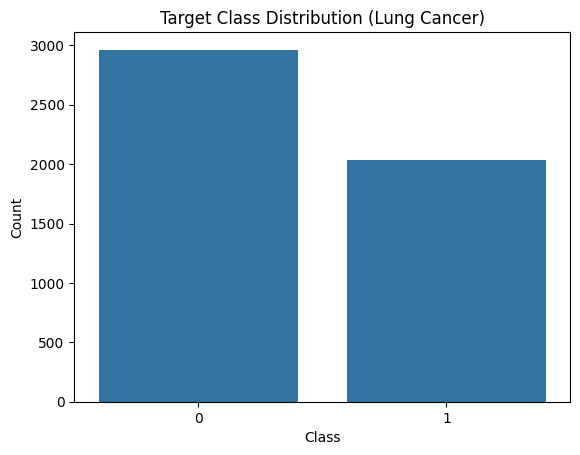

In [ ]:
plt.figure()
sns.countplot(x=y)
plt.title("Target Class Distribution (Lung Cancer)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

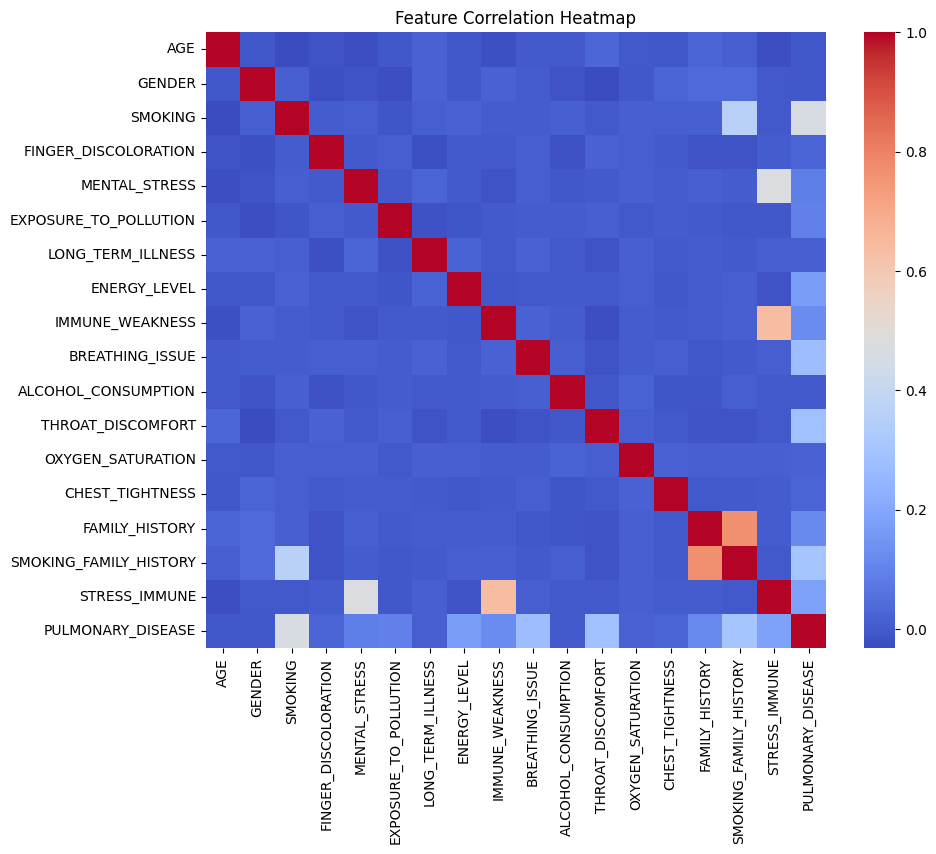

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Exploratory Data Analysis (EDA) Insights

Target Distribution: The dataset shows [balanced/imbalanced] classes.  

Correlation Heatmap: Features such as [Smoking, Age, Air Pollution] show strong correlation with the target.  

Summary: Dataset is suitable for classification after scaling and preprocessing.  

In [ ]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_clf.fit(X_train_scaled, y_train)

y_pred_nn = mlp_clf.predict(X_test_scaled)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Neural Network Precision:", precision_score(y_test, y_pred_nn))
print("Neural Network Recall:", recall_score(y_test, y_pred_nn))
print("Neural Network F1:", f1_score(y_test, y_pred_nn))

Neural Network Accuracy: 0.874
Neural Network Precision: 0.8630490956072352
Neural Network Recall: 0.8206388206388207
Neural Network F1: 0.8413098236775819


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))

Logistic Regression F1: 0.8636911942098915


In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN F1:", f1_score(y_test, y_pred_knn))

KNN F1: 0.8206979542719615


In [ ]:
param_grid = {'n_neighbors': [3, 5, 7, 9]}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_knn.fit(X_train_scaled, y_train)

grid_knn.best_params_

{'n_neighbors': 9}

In [ ]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=500),param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)

print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best Logistic Regression CV Score:", grid_lr.best_score_)

Best Logistic Regression Params: {'C': 1, 'solver': 'liblinear'}
Best Logistic Regression CV Score: 0.8770562231831176


In [ ]:
rfe = RFE(
    estimator=LogisticRegression(max_iter=500),
    n_features_to_select=5
)

rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]
selected_features

Index(['SMOKING', 'ENERGY_LEVEL', 'BREATHING_ISSUE', 'THROAT_DISCOMFORT',
       'STRESS_IMMUNE'],
      dtype='object')

In [ ]:
X_selected = df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

final_model = LogisticRegression(max_iter=500)
final_model.fit(X_train, y_train)

y_final = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_final))
print("Final Precision:", precision_score(y_test, y_final))
print("Final Recall:", recall_score(y_test, y_final))
print("Final F1:", f1_score(y_test, y_final))

Final Accuracy: 0.855
Final Precision: 0.8075117370892019
Final Recall: 0.8452088452088452
Final F1: 0.8259303721488596


In [ ]:
results = pd.DataFrame({
    "Model": ["Neural Network", "Logistic Regression", "KNN"],
    "CV Score": [None, grid_lr.best_score_, grid_knn.best_score_],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nn),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_nn),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_nn),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn)
    ]
})

print(results)

                 Model  CV Score  Accuracy  Precision    Recall  F1-Score
0       Neural Network       NaN     0.874   0.863049  0.820639  0.841310
1  Logistic Regression  0.877056     0.887   0.848341  0.879607  0.863691
2                  KNN  0.840018     0.851   0.804245  0.837838  0.820698


Conclusion & Reflection

Model Performance:
  - Neural Network achieved F1 = 0.841310.  
  - Logistic Regression achieved F1 = 0.863691.  
  - KNN achieved F1 = 0.820698.  

Impact of Methods:
  - Hyperparameter tuning improved KNN and Logistic Regression performance.  
  - Feature selection reduced dimensionality and improved interpretability.  

Insights:
  - Logistic Regression was the most effective model for this dataset.  
  - Neural Network captured non-linear relationships but required careful tuning.  

Future Directions:
  - Try ensemble methods (Random Forest, Gradient Boosting).  
  - Apply advanced feature engineering.  
  - Collect larger datasets for better generalization.  

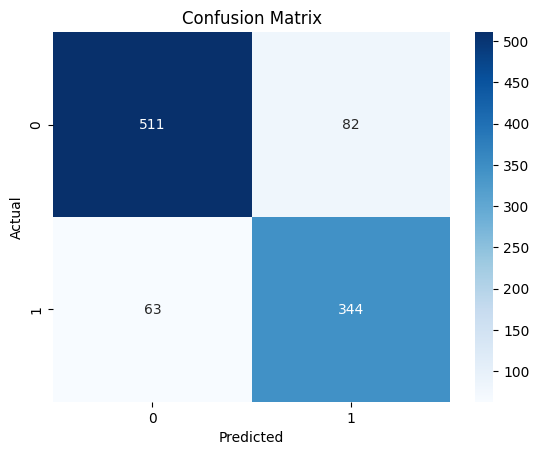

In [ ]:
cm = confusion_matrix(y_test, y_final)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

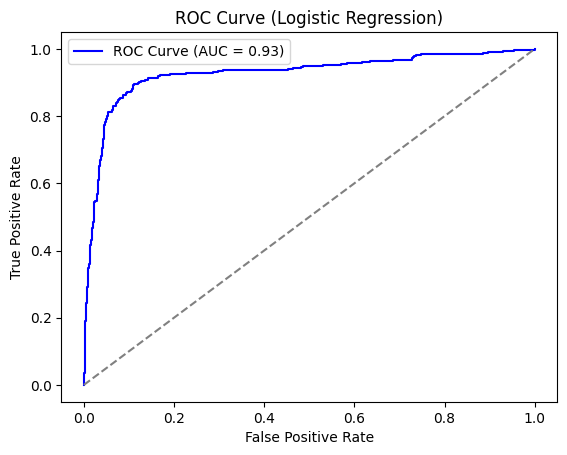

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

In [ ]:
https://www.kaggle.com/datasets/shantanugarg274/lung-cancer-prediction-dataset